Device: cpu
Fetching and preprocessing irregular USGS earthquake data...

--- Training Standard GRU ---
Epoch 05/20 | Loss: 13.8673
Epoch 10/20 | Loss: 10.2037
Epoch 15/20 | Loss: 4.8701
Epoch 20/20 | Loss: 1.4719

--- Training ODE-RNN (Neural ODE) ---
Epoch 02/10 | Loss: 14.3746
Epoch 04/10 | Loss: 12.5877
Epoch 06/10 | Loss: 9.2935
Epoch 08/10 | Loss: 4.0797
Epoch 10/10 | Loss: 4.4627

FINAL EVALUATION ON TEST SET
Standard GRU Test MSE: 1.2777
ODE-RNN (Neural ODE) Test MSE: 3.6444


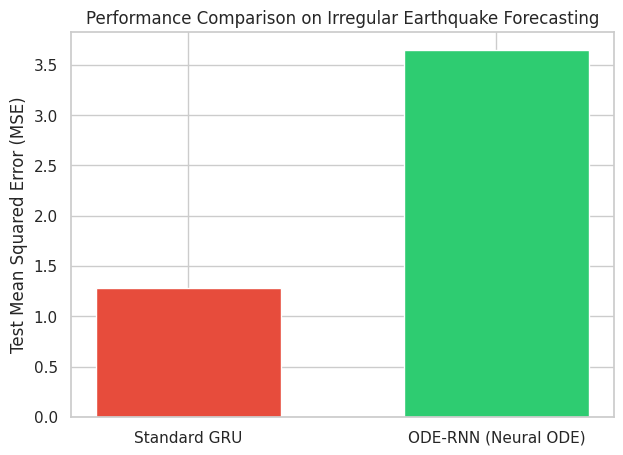

In [ ]:
# ==========================================
# Install & Setup
# ==========================================

!pip install -q torchdiffeq  # download solver

import os  # system tools
import warnings  # hide warnings
import pandas as pd  # table data
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.optim as optim  # model trainers
from torchdiffeq import odeint  # math solver
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # styling plots
from sklearn.preprocessing import StandardScaler  # scale values

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide logs
warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Continuous Math Model (ODE)
# ==========================================

class ODEFunc(nn.Module):  # rate of change network
    def __init__(self, hidden_dim):  # initialize layers
        super().__init__()  # parent init
        self.net = nn.Sequential(  # sequential layers
            nn.Linear(hidden_dim, hidden_dim * 2),  # double dimensions - Linear: Fully-connected layer transforming hidden_dim inputs to hidden_dim * 2 outputs - expands feature space before activation.
            nn.Tanh(),  # activation function # Tanh: Hyperbolic tangent activation - outputs between -1 and 1, zero-centered, helps with gradient flow in ODE networks.
            nn.Linear(hidden_dim * 2, hidden_dim)  # shrink dimensions - Linear: Shrinks back from hidden_dim * 2 to hidden_dim - compresses features after activation, maintaining ODE network stability.
        )  # end network

    def forward(self, t, h):  # forward pass
        return self.net(h)  # predict derivative

# ==========================================
# Recurrent ODE Network
# ==========================================

class ODERNN(nn.Module):  # time-gap network
    def __init__(self, input_dim, hidden_dim, output_dim):  # initialize layers
        super().__init__()  # parent init
        self.hidden_dim = hidden_dim  # save size
        self.ode_func = ODEFunc(hidden_dim)  # load solver - ODEFunc: Neural network that models the derivative (rate of change) of hidden states, used by the ODE solver to continuously evolve states over time.
        self.gru_cell = nn.GRUCell(input_dim, hidden_dim)  # standard gru - GRUCell: Gated Recurrent Unit cell - processes sequential inputs, updates hidden state using update/reset gates, handles irregular time steps.
        self.regressor = nn.Linear(hidden_dim, output_dim)  # output layer - Linear: Final layer mapping hidden state to output_dim - produces prediction from learned time-series representation.

    def forward(self, x, t):  # forward pass
        batch_size, seq_len, input_dim = x.shape  # unpack dimensions
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)  # initial state

        for i in range(seq_len):  # loop sequence
            if i > 0:  # check step
                h_new = []  # holding list
                for b_idx in range(batch_size):  # loop batch
                    dt = t[b_idx, i] - t[b_idx, i-1]  # find time gap
                    if dt > 0:  # positive gap
                        t_span = torch.tensor([0.0, dt.item()], device=x.device)  # time span - Creates integration interval from 0 to dt for ODE solver - defines how long the neural ODE evolves between observations based on actual time gap.
                        sol = odeint(self.ode_func, h[b_idx], t_span)  # run integration - ODE Integration: Solves the neural ODE using odeint - evolves hidden state over time interval using the learned derivative function, handling irregular time gaps.
                        h_new.append(sol[-1])  # save state - Save State: Stores the final hidden state after ODE integration - captures continuous evolution over the irregular time interval.
                    else:  # zero gap
                        h_new.append(h[b_idx])  # keep state
                h = torch.stack(h_new)  # rebuild state

            h = self.gru_cell(x[:, i, :], h)  # update state

        return self.regressor(h)  # return predictions

# ==========================================
# Standard Recurrent Network
# ==========================================

class StandardRNN(nn.Module):  # standard baseline
    def __init__(self, input_dim, hidden_dim, output_dim):  # initialize layers
        super().__init__()  # parent init
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)  # normal gru - GRU: Standard Gated Recurrent Unit with batch_first=True - processes sequences in batch-major format (batch, sequence, features), ignores time gaps.
        self.regressor = nn.Linear(hidden_dim, output_dim)  # output layer - Linear: Final layer mapping hidden state to output_dim - produces prediction from learned time-series representation.

    def forward(self, x):  # forward pass
        out, _ = self.rnn(x)  # run sequence
        last_out = out[:, -1, :]  # get last
        return self.regressor(last_out)  # return prediction

# ==========================================
# Fetch Earthquake Data
# ==========================================

def prepare_real_irregular_data(seq_len=10):  # data helper
    url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/2.5_month.csv"  # data feed
    df = pd.read_csv(url)  # load csv

    df['time'] = pd.to_datetime(df['time'])  # parse dates
    df = df.sort_values('time').reset_index(drop=True)  # sort chronologically
    df = df.dropna(subset=['latitude', 'longitude', 'depth', 'mag'])  # drop empty

    df['time_diff'] = df['time'].diff().dt.total_seconds() / 3600.0  # hourly differences
    df['time_diff'] = df['time_diff'].fillna(0.0)  # fill first

    scaler = StandardScaler()  # scale helper
    coords = scaler.fit_transform(df[['latitude', 'longitude', 'depth']].values)  # scale coordinates
    mags = df['mag'].values  # targets array
    time_gaps = df['time_diff'].values  # gaps array

    X_seq = []  # inputs list
    T_seq = []  # times list
    y_target = []  # outputs list

    for i in range(min(500, len(df) - seq_len)):  # loop data
        X_seq.append(coords[i:i+seq_len])  # append coordinate
        gaps = time_gaps[i:i+seq_len]  # get gaps
        T_seq.append(np.cumsum(gaps))  # accumulate timelines
        y_target.append(mags[i+seq_len])  # append targets

    X_seq = torch.FloatTensor(np.array(X_seq))  # inputs tensor
    T_seq = torch.FloatTensor(np.array(T_seq))  # timeline tensor
    y_target = torch.FloatTensor(np.array(y_target)).unsqueeze(-1)  # targets tensor

    split = int(0.8 * len(X_seq))  # split ratio
    train_data = (X_seq[:split], T_seq[:split], y_target[:split])  # train slice
    test_data = (X_seq[split:], T_seq[split:], y_target[split:])  # test slice

    return train_data, test_data  # return datasets

# ==========================================
# Run Training & Plot
# ==========================================

def run_neural_ode_analysis():  # main execution
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # check gpu
    print(f"Device: {device}")  # print device

    print("Fetching and preprocessing irregular USGS earthquake data...")  # print status
    try:  # try block
        train_data, test_data = prepare_real_irregular_data(seq_len=10)  # load real
    except Exception as e:  # fallback block
        print(f"Error: {e}. Using synthetic data...")  # print error
        X_train = torch.randn(100, 10, 3)  # fake train
        T_train = torch.cumsum(torch.rand(100, 10), dim=1)  # fake train time
        y_train = torch.randn(100, 1)  # fake train target
        X_test = torch.randn(50, 10, 3)  # fake test
        T_test = torch.cumsum(torch.rand(50, 10), dim=1)  # fake test time
        y_test = torch.randn(50, 1)  # fake test target
        train_data = (X_train, T_train, y_train)  # pack train
        test_data = (X_test, T_test, y_test)  # pack test

    X_train, T_train, y_train = train_data  # unpack train
    X_test, T_test, y_test = test_data  # unpack test

    X_train, T_train, y_train = X_train.to(device), T_train.to(device), y_train.to(device)  # load device
    X_test, T_test, y_test = X_test.to(device), T_test.to(device), y_test.to(device)  # load device

    input_dim = X_train.shape[-1]  # feature count
    hidden_dim = 16  # neuron count
    output_dim = 1  # outcome count

    ode_rnn = ODERNN(input_dim, hidden_dim, output_dim).to(device)  # load ode-rnn
    std_rnn = StandardRNN(input_dim, hidden_dim, output_dim).to(device)  # load standard

    criterion = nn.MSELoss()  # loss metric
    optimizer_std = optim.Adam(std_rnn.parameters(), lr=0.01)  # baseline optimizer
    optimizer_ode = optim.Adam(ode_rnn.parameters(), lr=0.01)  # ode optimizer

    print("\n--- Training Standard GRU ---")  # print status
    std_rnn.train()  # set training
    for epoch in range(20):  # loop epochs
        optimizer_std.zero_grad()  # zero gradients
        outputs = std_rnn(X_train)  # calculate outputs
        loss = criterion(outputs, y_train)  # calculate loss
        loss.backward()  # backpropagation
        optimizer_std.step()  # update weights
        if (epoch+1) % 5 == 0:  # interval check
            print(f"Epoch {epoch+1:02d}/20 | Loss: {loss.item():.4f}")  # print loss

    print("\n--- Training ODE-RNN (Neural ODE) ---")  # print status
    ode_rnn.train()  # set training
    for epoch in range(10):  # loop epochs
        optimizer_ode.zero_grad()  # zero gradients
        outputs = ode_rnn(X_train, T_train)  # calculate outputs
        loss = criterion(outputs, y_train)  # calculate loss
        loss.backward()  # backpropagation
        optimizer_ode.step()  # update weights
        if (epoch+1) % 2 == 0:  # interval check
            print(f"Epoch {epoch+1:02d}/10 | Loss: {loss.item():.4f}")  # print loss

    std_rnn.eval()  # set eval
    ode_rnn.eval()  # set eval
    with torch.no_grad():  # freeze gradients
        test_loss_std = criterion(std_rnn(X_test), y_test).item()  # evaluate standard
        test_loss_ode = criterion(ode_rnn(X_test, T_test), y_test).item()  # evaluate ode

    print("\n=====================================")  # layout divider
    print("FINAL EVALUATION ON TEST SET")  # header
    print("=====================================")  # layout divider
    print(f"Standard GRU Test MSE: {test_loss_std:.4f}")  # print standard performance
    print(f"ODE-RNN (Neural ODE) Test MSE: {test_loss_ode:.4f}")  # print ode performance
    print("=====================================")  # layout divider

    sns.set_theme(style="whitegrid")  # set theme
    plt.figure(figsize=(7, 5))  # canvas size
    plt.bar(['Standard GRU', 'ODE-RNN (Neural ODE)'], [test_loss_std, test_loss_ode], color=['#e74c3c', '#2ecc71'], width=0.6)  # build bars
    plt.ylabel('Test Mean Squared Error (MSE)')  # y-axis label
    plt.title('Performance Comparison on Irregular Earthquake Forecasting')  # plot title
    plt.show()  # draw plot

if __name__ == '__main__':  # execution entry
    run_neural_ode_analysis()  # run script